# Statistics Final Exam: 
## Statistical Analysis of the Bullet Cluster
#### Renzo
#### Roberto
#### Thiele
#### Juan David Galan Vargas

### Libraries and Models

In [4]:
import numpy as np
import matplotlib . pyplot as plt
from scipy.optimize import minimize , curve_fit
from scipy.stats import chi2 as chi2dist , norm as normdist
from scipy.stats import t as tdist , f as fdist , kstest
from scipy.integrate import quad
import pandas as pd
import warnings
warnings.filterwarnings ("ignore")


In [2]:
# PROVIDED MODELS ---

def model_2gauss(x , A1 , mu1 , sig1 , A2 , mu2 , sig2 ):
    #" " " Two - component Gaussian profile . " " "
    return ( A1 * np . exp ( -(x - mu1 ) **2/(2* sig1 **2) ) + A2 * np . exp ( -(x - mu2 ) **2/(2* sig2 **2) ) )
def model_1gauss (x , A1 , mu1 , sig1 ) :
#" " " Single - component Gaussian profile . " " "
    return A1 * np . exp ( -(x - mu1 ) **2/(2* sig1 **2) )

def model_2beta (x , S1 , x1 , r1 , b1 , S2 , x2, r2, b2):
#" " " Two - component beta profile . " " "
    return ( S1 /(1+(( x - x1 ) / r1 ) **2) ** b1 + S2 /(1+(( x - x2 ) / r2 ) **2) ** b2 )
def model_1beta (x , S1 , x1 , r1 , b1 ) :
#" " " Single - component beta profile . " " "
    return S1 /(1+(( x - x1 ) / r1 ) **2) ** b1
#
# PHYSICAL CONSTANTS --- PROVIDED
#
arcmin_to_Mpc = 0.157 # 1 arcmin at z =0.296
M_per_gal= 2e11 # Msun per galaxy
M_per_SX= 1.5e10# Msun per X - ray count
M_per_kappa = 3e14# Msun per unit integrated kappa

### Part 0: Data

In [6]:
data=pd.read_csv("BulletClusterData.csv") #"z"

### Part 1: Redshift Distribution and Cluster Membership

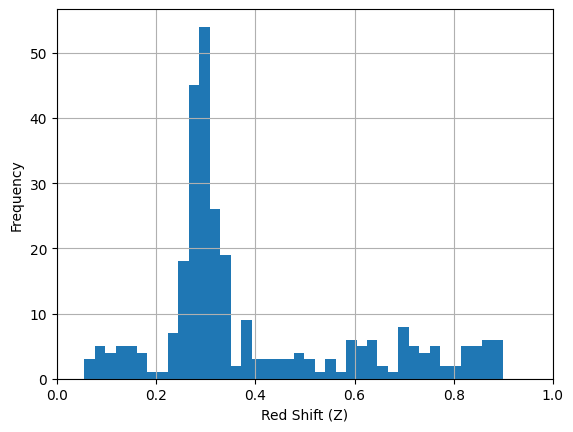

In [ ]:
# TODO 1.1 Plot the redshift histogram of z all using 40 bins over [0, 1].
# Identify the cluster peak visually. Label axes and add a title.
n, bins, patches = plt.hist(data["z"],bins=40)
plt.ylabel("Frequency")
plt.xlabel("Red Shift (Z)")
plt.xlim((0,1))
plt.grid("True")
plt.show()


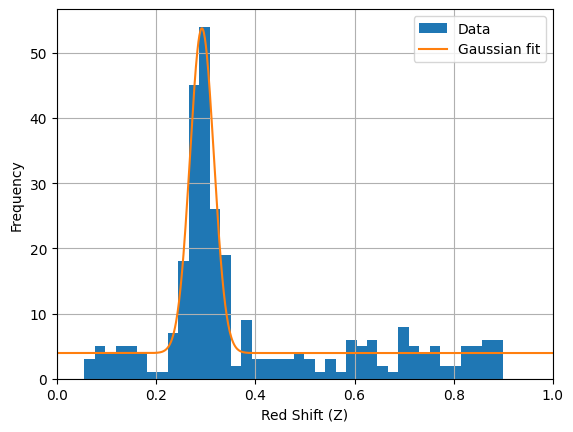

Parameter: Z_cl: 0.292360011589899 . Standar Deviation Error: 0.001221688613203904
Parameter: Sigma_cl: 0.024057043815003728 . Standar Deviation Error: 0.0012576056749231193


In [49]:
#Fit a Gaussian+background model to the cluster peak using MLE:
bins_center=[]
for i in range(len(bins)-1):
    lower_lim= bins[i]
    upper_lim= bins[i+1]
    center= (lower_lim+upper_lim)/2
    bins_center.append(center)


def gaussian_plus_background(z,A,z_cl,sigma_cl,C):
    return A* np.exp((-1*(z-z_cl)**2)/(2* sigma_cl**2)) + C


x= np.linspace(0,1,1000)
popt, pcov = curve_fit(gaussian_plus_background,bins_center,n)
plt.hist(data["z"],bins=40, label="Data")
plt.ylabel("Frequency")
plt.xlabel("Red Shift (Z)")
plt.xlim((0,1))
plt.grid("True")
plt.plot(x,gaussian_plus_background(x, *popt),label="Gaussian fit")
plt.legend()
plt.show()
perr = np.sqrt(np.diag(pcov))
print("Parameter: Z_cl: "+str(popt[1])+" . Standar Deviation Error: "+str(perr[1]))
print("Parameter: Sigma_cl: "+str(popt[2])+" . Standar Deviation Error: "+str(perr[2]))
z_cl=popt[1]
sigma_cl=popt[2]


In [53]:
#Define cluster membership: a galaxy belongs to the cluster if |z − ẑcl| < 3σ̂cl.
#Count how many galaxies satisfy this criterion. Report the fraction of members vs. total.
member_counter=0
for i in data["z"]:
    #print(i)
    if np.abs(i - z_cl) < 3*sigma_cl:
        member_counter+=1
fracc=member_counter/len(data["z"])
print("fraction of galaxies that belong to the cluster: "+str(fracc))
member_counter=0
for i in data["z"]:
    #print(i)
    if np.abs(i - z_cl) < 2*sigma_cl:
        member_counter+=1
fracc_2sigma=member_counter/len(data["z"])
print("fraction of galaxies that belong to the cluster (2 sigma_CL): "+str(fracc_2sigma))
member_counter=0
for i in data["z"]:
    #print(i)
    if np.abs(i - z_cl) < sigma_cl:
        member_counter+=1
fracc_1sigma=member_counter/len(data["z"])
print("fraction of galaxies that belong to the cluster (1 sigma_CL): "+str(fracc_1sigma))

fraction of galaxies that belong to the cluster: 0.57
fraction of galaxies that belong to the cluster (2 sigma_CL): 0.5333333333333333
fraction of galaxies that belong to the cluster (1 sigma_CL): 0.35


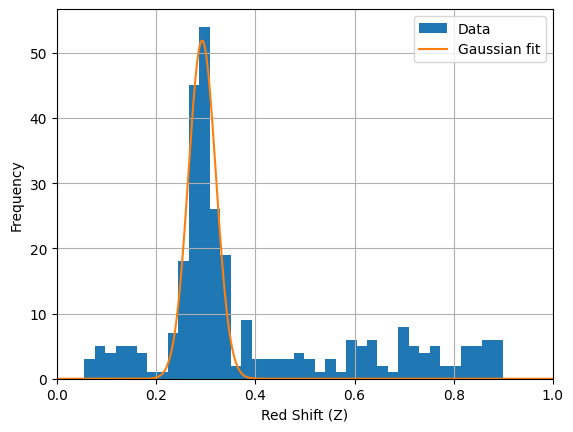

Parameter: Z_cl: 0.2927960627711147 . Standar Deviation Error: 0.0022238739994477285
Parameter: Sigma_cl: 0.02762430242534291 . Standar Deviation Error: 0.0022238717550833427


In [ ]:
#Compute χ̃2 for the Gaussian+background fit. Is the fit acceptable?
# Compare with a single Gaussian (no C) and comment on the difference. (model1_gauss)



x= np.linspace(0,1,1000)
popt, pcov = curve_fit(model_1gauss,bins_center,n)
plt.hist(data["z"],bins=40, label="Data")
plt.ylabel("Frequency")
plt.xlabel("Red Shift (Z)")
plt.xlim((0,1))
plt.grid("True")
plt.plot(x,model_1gauss(x, *popt),label="Gaussian fit")
plt.legend()
plt.show()
perr = np.sqrt(np.diag(pcov))
print("Parameter: Z_cl: "+str(popt[1])+" . Standar Deviation Error: "+str(perr[1]))
print("Parameter: Sigma_cl: "+str(popt[2])+" . Standar Deviation Error: "+str(perr[2]))
z_cl=popt[1]
sigma_cl=popt[2]